<div style="background:linear-gradient(135deg, rgba(249,112,102,0.18), rgba(249,112,102,0.02)); border-left:6px solid #F97066; border-radius:10px; padding:20px 24px; margin-bottom:20px;">
<h1 style="margin:0; color:#F97066; font-size:1.8em;">📋 Cheat Sheet de Machine Learning</h1>
<p style="margin:6px 0 0; opacity:0.8;">Conceptos prácticos y transversales a todo el curso, en un solo lugar de referencia rápida</p>
</div>

Este notebook es un **resumen de referencia**, no una nueva unidad: reúne, en formato compacto y con apoyo visual, conceptos que aparecen una y otra vez a lo largo del curso — sesgo y varianza, métricas de clasificación, PCA, regularización, arquitecturas de CNN, ensambles, y las estructuras de datos detrás de los algoritmos de búsqueda. Cada sección incluye sus fórmulas clave y al menos una demostración con datos y código reales (no solo el enunciado teórico).

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:14px 20px; margin:16px 0 24px; background:rgba(14,165,233,0.04);">
<strong>📑 Contenido de esta guía</strong>
<ol style="margin:8px 0 0; padding-left:20px;">
<li><a href="#sesgo-varianza">Sesgo y Varianza (Bias-Variance Tradeoff)</a></li>
<li><a href="#datos-desbalanceados">Datos Desbalanceados y Métricas de Clasificación</a></li>
<li><a href="#pca">Reducción de Dimensionalidad con PCA</a></li>
<li><a href="#bayes">Teorema de Bayes y Clasificador Naïve Bayes</a></li>
<li><a href="#regresion">Análisis de Regresión</a></li>
<li><a href="#regularizacion">Regularización en ML</a></li>
<li><a href="#cnn-bloques">Redes Neuronales Convolucionales: Bloques Básicos</a></li>
<li><a href="#cnn-famosas">CNNs Famosas</a></li>
<li><a href="#ensamble">Aprendizaje por Ensamble</a></li>
<li><a href="#estructuras-datos">Estructuras de Datos</a></li>
<li><a href="#cierre">Cierre</a></li>
</ol>
</div>

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Fuente</strong><br>
El contenido de este notebook está inspirado y adaptado de la serie de cheat sheets de Machine Learning de Aqeel Anwar (<a href="https://www.cheatsheets.aqeel-anwar.com">cheatsheets.aqeel-anwar.com</a>), traducido, reordenado y acompañado de demostraciones de código propias para este curso.
</div>

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(42)

# Paleta de colores consistente con el resto del curso
CORAL = "#F97066"
AZUL = "#0EA5E9"
INDIGO = "#6366F1"
TEAL = "#14B8A6"
GRIS = "#64748B"

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["font.size"] = 10


def estilizar(ax, titulo=None):
    """Aplica un estilo visual consistente a los ejes de una figura."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if titulo:
        ax.set_title(titulo, fontsize=11, fontweight="bold")


print("Utilidades de estilo cargadas correctamente.")

Utilidades de estilo cargadas correctamente.


<a id="sesgo-varianza"></a>

# <span style="color:#F97066;">1. Sesgo y Varianza (Bias-Variance Tradeoff)</span>

**Sesgo (bias)**: el error entre la predicción promedio del modelo y el valor real. Mide la capacidad del modelo subyacente para representar la relación real entre entradas y salidas.

$$bias = \mathbb{E}[\hat{f}(x)] - f(x)$$

**Varianza (variance)**: cuánto varía la predicción del modelo entre distintos conjuntos de entrenamiento. Mide qué tan sensible es el modelo a los datos específicos usados para entrenarlo.

$$variance = \mathbb{E}\left[\left(\hat{f}(x) - \mathbb{E}[\hat{f}(x)]\right)^2\right]$$

| | Modelo | Comportamiento | Error |
|---|---|---|---|
| **Alto sesgo** | Demasiado simple | Subajuste (*underfitting*) | Alto en entrenamiento y en prueba |
| **Alta varianza** | Demasiado complejo | Sobreajuste (*overfitting*) | Bajo en entrenamiento, alto en prueba — empieza a modelar el ruido |

Este concepto ya se trabajó en la práctica en <code>Unidad 4/1-fundamentos-redes-neuronales.ipynb</code>; aquí se retoma de forma visual y transversal a cualquier modelo, no solo redes neuronales.

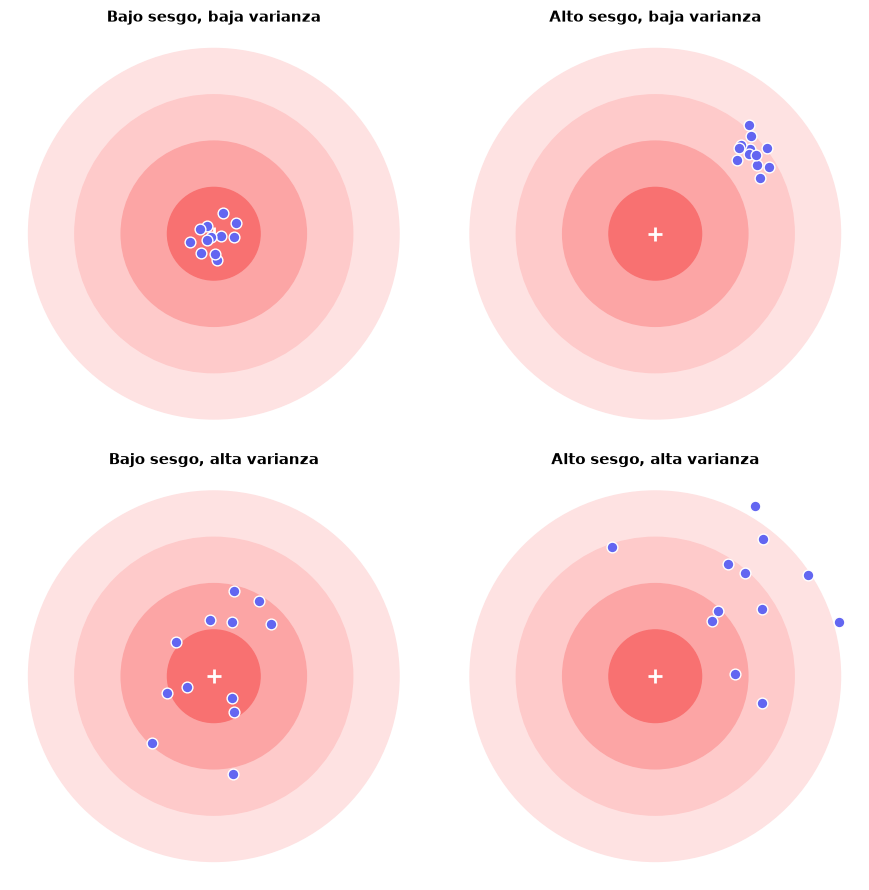

In [2]:
# Analogía del "tablero de dardos": cada panel es un modelo distinto,
# el centro del tablero es el valor verdadero, y cada punto es una predicción
# del modelo entrenado con una muestra distinta de datos.

fig, axes = plt.subplots(2, 2, figsize=(9, 9))
centro = np.array([0, 0])

configuraciones = [
    ("Bajo sesgo, baja varianza", centro, 0.15, axes[0, 0]),
    ("Alto sesgo, baja varianza", np.array([1.1, 0.9]), 0.15, axes[0, 1]),
    ("Bajo sesgo, alta varianza", centro, 0.6, axes[1, 0]),
    ("Alto sesgo, alta varianza", np.array([1.1, 0.9]), 0.6, axes[1, 1]),
]

for titulo, centro_predicciones, dispersion, ax in configuraciones:
    # Dibujar el tablero de dardos (círculos concéntricos)
    for radio, color in zip([2.0, 1.5, 1.0, 0.5], ["#FEE2E2", "#FECACA", "#FCA5A5", "#F87171"]):
        ax.add_patch(plt.Circle((0, 0), radio, color=color, zorder=1))
    ax.plot(0, 0, "+", color="white", markersize=10, mew=2, zorder=3)

    # Simular 12 predicciones del modelo alrededor de su centro de predicciones
    puntos = centro_predicciones + np.random.normal(0, dispersion, size=(12, 2))
    ax.scatter(puntos[:, 0], puntos[:, 1], color=INDIGO, edgecolor="white", s=60, zorder=4)

    ax.set_xlim(-2.2, 2.2)
    ax.set_ylim(-2.2, 2.2)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    estilizar(ax, titulo)
    for spine in ax.spines.values():
        spine.set_visible(False)

plt.tight_layout()
plt.show()

- El **sesgo** se ve en qué tan lejos está el grupo de predicciones del centro del tablero (el valor real): lejos del centro = alto sesgo.
- La **varianza** se ve en qué tan dispersas están las predicciones entre sí: muy dispersas = alta varianza.
- El panel ideal (arriba-izquierda) es el que se busca: predicciones cerca del centro y poco dispersas entre sí.

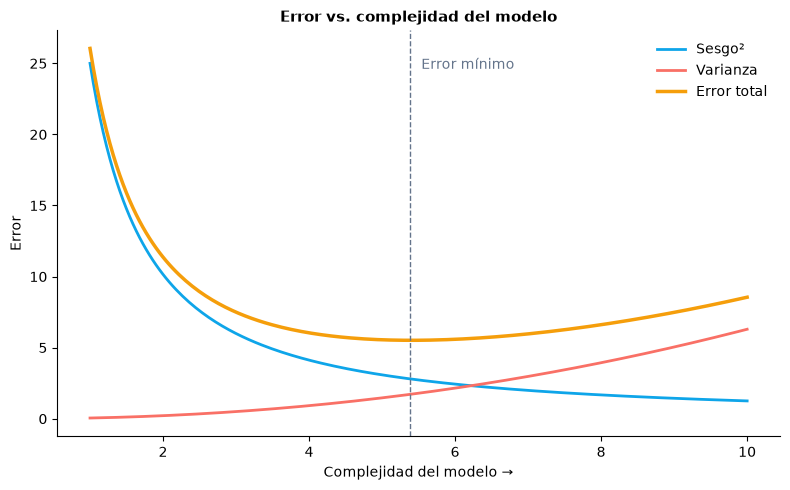

La complejidad con menor error total en esta simulación es ≈ 5.4


In [3]:
# Curva de error vs. complejidad del modelo: el sesgo al cuadrado decrece,
# la varianza crece, y el error total (mas el error irreducible) tiene un mínimo.

complejidad = np.linspace(1, 10, 200)
sesgo_cuadrado = 25 / complejidad**1.3
varianza = 0.05 * complejidad**2.1
error_irreducible = 1.0
error_total = sesgo_cuadrado + varianza + error_irreducible

complejidad_optima = complejidad[np.argmin(error_total)]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(complejidad, sesgo_cuadrado, color=AZUL, label="Sesgo²", linewidth=2)
ax.plot(complejidad, varianza, color=CORAL, label="Varianza", linewidth=2)
ax.plot(complejidad, error_total, color="#F59E0B", label="Error total", linewidth=2.5)
ax.axvline(complejidad_optima, color=GRIS, linestyle="--", linewidth=1)
ax.text(complejidad_optima + 0.15, ax.get_ylim()[1] * 0.9, "Error mínimo", color=GRIS)

ax.set_xlabel("Complejidad del modelo →")
ax.set_ylabel("Error")
ax.legend(frameon=False)
estilizar(ax, "Error vs. complejidad del modelo")
plt.tight_layout()
plt.show()

print(f"La complejidad con menor error total en esta simulación es ≈ {complejidad_optima:.1f}")

<span style="color:#F97066;">Subajuste, ajuste correcto y sobreajuste, con datos reales</span>

Para verlo con un modelo concreto: se generan datos ruidosos a partir de una función seno, y se ajustan tres polinomios de distinto grado — uno demasiado simple, uno razonable, y uno demasiado complejo.

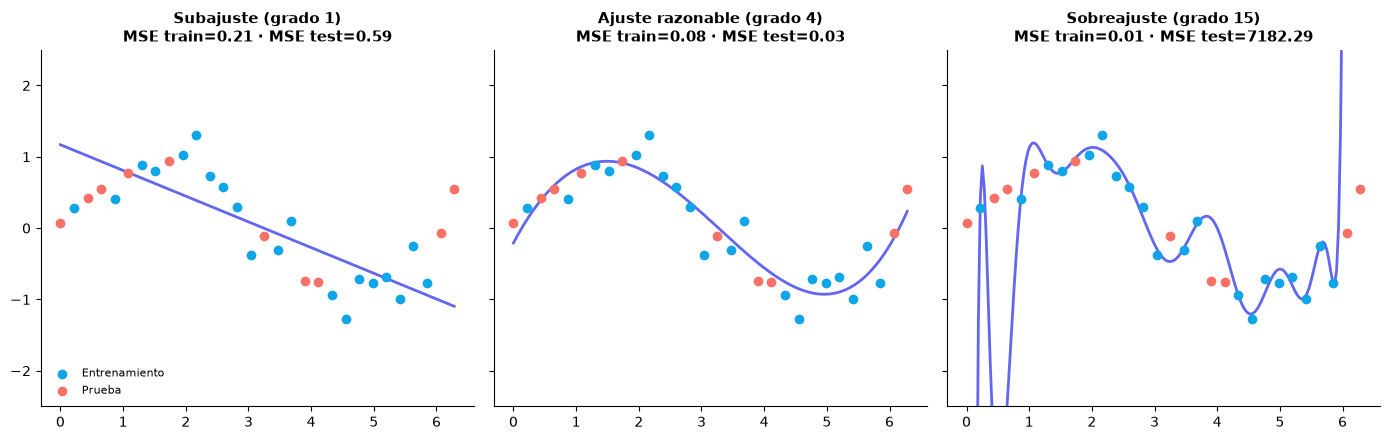

In [4]:
from sklearn.metrics import mean_squared_error

# 1. Generar datos ruidosos a partir de una función seno conocida
x_completo = np.linspace(0, 2 * np.pi, 30)
y_completo = np.sin(x_completo) + np.random.normal(0, 0.25, size=x_completo.shape)

# 2. Separar en entrenamiento y prueba
indices = np.random.permutation(len(x_completo))
idx_train, idx_test = indices[:20], indices[20:]
x_train, y_train = x_completo[idx_train], y_completo[idx_train]
x_test, y_test = x_completo[idx_test], y_completo[idx_test]

x_curva = np.linspace(0, 2 * np.pi, 200)
grados = [1, 4, 15]
titulos = ["Subajuste (grado 1)", "Ajuste razonable (grado 4)", "Sobreajuste (grado 15)"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), sharey=True)

for grado, titulo, ax in zip(grados, titulos, axes):
    coeficientes = np.polyfit(x_train, y_train, grado)
    polinomio = np.poly1d(coeficientes)

    error_train = mean_squared_error(y_train, polinomio(x_train))
    error_test = mean_squared_error(y_test, polinomio(x_test))

    ax.scatter(x_train, y_train, color=AZUL, label="Entrenamiento", zorder=3)
    ax.scatter(x_test, y_test, color=CORAL, label="Prueba", zorder=3)
    ax.plot(x_curva, polinomio(x_curva), color=INDIGO, linewidth=2)
    ax.set_ylim(-2.5, 2.5)
    estilizar(ax, f"{titulo}\nMSE train={error_train:.2f} · MSE test={error_test:.2f}")

axes[0].legend(frameon=False, loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

El polinomio de grado 1 no logra capturar la forma de la curva (error alto en ambos conjuntos — subajuste). El de grado 15 pasa casi exactamente por cada punto de entrenamiento (error de entrenamiento muy bajo) pero oscila de forma errática entre esos puntos, con un error de prueba mucho más alto — la firma clásica del sobreajuste. El de grado 4 logra el mejor balance.

<div style="border-left:4px solid #6366F1; background:rgba(99,102,241,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>📝 Compromiso sesgo-varianza</strong><br>

$$Error = Sesgo^2 + Varianza + Error\ irreducible$$

Aumentar la complejidad del modelo generalmente reduce el sesgo pero aumenta la varianza, y viceversa. El mejor modelo no es el más complejo ni el más simple, sino el que minimiza esta suma — exactamente el punto marcado en la curva de la figura anterior.
</div>

---

<a id="datos-desbalanceados"></a>

# <span style="color:#F97066;">2. Datos Desbalanceados y Métricas de Clasificación</span>

Un clasificador que **siempre predice la clase mayoritaria** puede alcanzar una exactitud (*accuracy*) engañosamente alta cuando las clases están desbalanceadas — por ejemplo, 90% de exactitud con solo predecir "azul" si el 90% de los datos son azules, sin haber aprendido nada útil.

<div style="border:1px solid rgba(14,165,233,0.35); border-radius:10px; padding:16px 20px; margin:16px 0; background:rgba(14,165,233,0.04);">
<table style="width:100%; border-collapse:collapse;">
<tr style="background:#0EA5E9; color:white;">
<th style="padding:8px; text-align:left;">Métrica</th>
<th style="padding:8px; text-align:left;">Fórmula</th>
<th style="padding:8px; text-align:left;">Responde a</th>
</tr>
<tr style="background:rgba(14,165,233,0.07);"><td style="padding:8px;"><strong>Exactitud (Accuracy)</strong></td><td style="padding:8px;">$\frac{TP+TN}{TP+FP+FN+TN}$</td><td style="padding:8px;">¿Qué porcentaje total acerté?</td></tr>
<tr><td style="padding:8px;"><strong>Precisión (Precision)</strong></td><td style="padding:8px;">$\frac{TP}{TP+FP}$</td><td style="padding:8px;">De lo que predije positivo, ¿cuánto lo era realmente?</td></tr>
<tr style="background:rgba(14,165,233,0.07);"><td style="padding:8px;"><strong>Sensibilidad / Recall</strong></td><td style="padding:8px;">$\frac{TP}{TP+FN}$</td><td style="padding:8px;">De todos los positivos reales, ¿cuántos detecté?</td></tr>
<tr><td style="padding:8px;"><strong>Especificidad</strong></td><td style="padding:8px;">$\frac{TN}{TN+FP}$</td><td style="padding:8px;">De todos los negativos reales, ¿cuántos identifiqué bien?</td></tr>
<tr style="background:rgba(14,165,233,0.07);"><td style="padding:8px;"><strong>Tasa de falsos positivos</strong></td><td style="padding:8px;">$\frac{FP}{TN+FP}$</td><td style="padding:8px;">¿Qué tan seguido me equivoco con los negativos?</td></tr>
<tr><td style="padding:8px;"><strong>F1 Score</strong></td><td style="padding:8px;">$2\times\frac{Prec \times Rec}{Prec + Rec}$</td><td style="padding:8px;">Media armónica entre precisión y recall</td></tr>
</table>
</div>

Esta tabla es la misma vista con más detalle en <code>Unidad 3/6-pipelines-evaluacion.ipynb</code>; aquí se retoma junto a una demostración concreta de por qué la exactitud sola puede engañar.

In [5]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, ConfusionMatrixDisplay
)

# 1. Un dataset sintético fuertemente desbalanceado: 95% clase 0, 5% clase 1
X, y = make_classification(
    n_samples=2000, n_features=6, n_informative=4,
    weights=[0.95, 0.05], random_state=42,
)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Proporción de la clase 1 en los datos: {y.mean():.1%}")

# 2. Un clasificador "tonto" que siempre predice la clase mayoritaria
ingenuo = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
pred_ingenuo = ingenuo.predict(X_test)

# 3. Un modelo real, entrenado normalmente
modelo = LogisticRegression().fit(X_train, y_train)
pred_modelo = modelo.predict(X_test)

for nombre, pred in [("Clasificador ingenuo", pred_ingenuo), ("Regresión logística", pred_modelo)]:
    print(f"\n{nombre}:")
    print(f"  Exactitud : {accuracy_score(y_test, pred):.2f}")
    print(f"  Precisión : {precision_score(y_test, pred, zero_division=0):.2f}")
    print(f"  Recall    : {recall_score(y_test, pred, zero_division=0):.2f}")
    print(f"  F1        : {f1_score(y_test, pred, zero_division=0):.2f}")

Proporción de la clase 1 en los datos: 5.1%

Clasificador ingenuo:
  Exactitud : 0.95
  Precisión : 0.00
  Recall    : 0.00
  F1        : 0.00

Regresión logística:
  Exactitud : 0.95
  Precisión : 0.00
  Recall    : 0.00
  F1        : 0.00


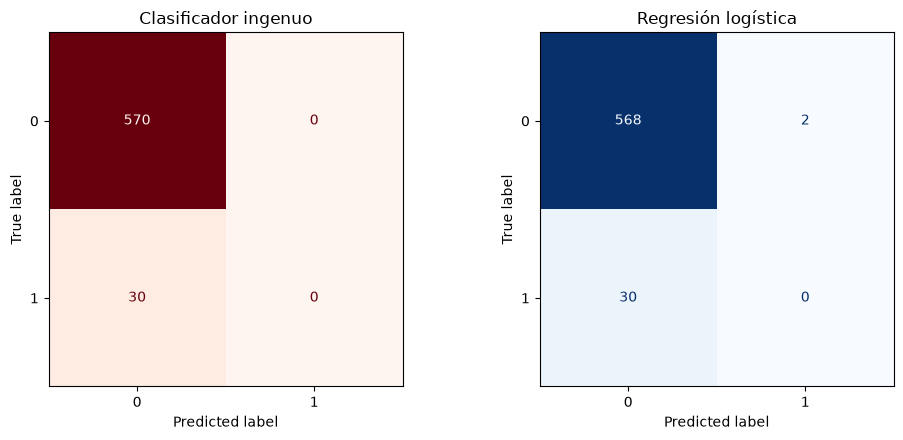

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_ingenuo, ax=axes[0], cmap="Reds", colorbar=False)
ConfusionMatrixDisplay.from_predictions(y_test, pred_modelo, ax=axes[1], cmap="Blues", colorbar=False)
axes[0].set_title("Clasificador ingenuo")
axes[1].set_title("Regresión logística")
plt.tight_layout()
plt.show()

El clasificador ingenuo alcanza una exactitud alta (cercana al 95%, igual a la proporción de la clase mayoritaria) sin haber detectado ni un solo caso de la clase 1 — su recall y su precisión sobre esa clase son 0. La regresión logística tiene una exactitud más baja o similar, pero su F1 sobre la clase minoritaria es muchísimo mayor: es el modelo que realmente aprendió algo útil. Esta es la razón por la que, en datasets desbalanceados, reportar solo exactitud es engañoso.

<span style="color:#F97066;">Posibles soluciones ante datos desbalanceados</span>

1. **Replicar datos**: repetir las muestras de la clase minoritaria hasta emparejar su número con la clase mayoritaria.
2. **Datos sintéticos**: generar variaciones de los datos existentes (rotar, recortar, añadir ruido en imágenes; SMOTE para datos tabulares — ver <code>Unidad 3/6-pipelines-evaluacion.ipynb</code>).
3. **Modificar la función de pérdida**: penalizar más los errores sobre la clase minoritaria (`class_weight="balanced"` en scikit-learn).
4. **Cambiar de algoritmo**: aumentar la complejidad del modelo para que las clases sean separables (con el riesgo de sobreajustar).

In [7]:
# Demostración rápida de la solución #3: ponderar la clase minoritaria en la pérdida

modelo_balanceado = LogisticRegression(class_weight="balanced").fit(X_train, y_train)
pred_balanceado = modelo_balanceado.predict(X_test)

print("Regresión logística con class_weight=\"balanced\":")
print(f"  Exactitud : {accuracy_score(y_test, pred_balanceado):.2f}")
print(f"  Precisión : {precision_score(y_test, pred_balanceado, zero_division=0):.2f}")
print(f"  Recall    : {recall_score(y_test, pred_balanceado, zero_division=0):.2f}")
print(f"  F1        : {f1_score(y_test, pred_balanceado, zero_division=0):.2f}")

Regresión logística con class_weight="balanced":
  Exactitud : 0.74
  Precisión : 0.13
  Recall    : 0.73
  F1        : 0.22


Al ponderar la clase minoritaria, el recall sube considerablemente — el modelo detecta muchos más casos positivos reales — típicamente a costa de una precisión algo menor. Este es exactamente el tipo de decisión de negocio (¿qué error cuesta más, un falso positivo o un falso negativo?) que ya se discutió en <code>Unidad 3/6-pipelines-evaluacion.ipynb</code>.

---

<a id="pca"></a>

# <span style="color:#F97066;">3. Reducción de Dimensionalidad con PCA</span>

**PCA** (*Principal Component Analysis*) busca un nuevo conjunto de ejes (ortogonales entre sí) en los que la dispersión (varianza) de los datos sea máxima en el primer eje, algo menor en el segundo, y así sucesivamente. La varianza en la dirección de un eje se interpreta como la cantidad de información que ese eje conserva.

**Pasos:**
1. Estandarizar los datos: $X_{new} = \frac{X - mean(X)}{std(X)}$
2. Calcular la matriz de covarianza: $C[i,j] = cov(x_i, x_j)$
3. Descomponer en autovalores y autovectores: $C = V\Sigma V^{-1}$
4. Ordenar los autovalores (y sus autovectores) de mayor a menor

Para reducir dimensionalidad, se conservan solo los primeros $m$ autovectores (los de mayor autovalor) y se proyectan los datos sobre ellos — son los $m$ ejes que preservan la mayor cantidad de información posible con solo $m$ dimensiones. Este mismo procedimiento se usó en la práctica en <code>Unidad 3/4-aprendizaje-no-supervisado.ipynb</code>.

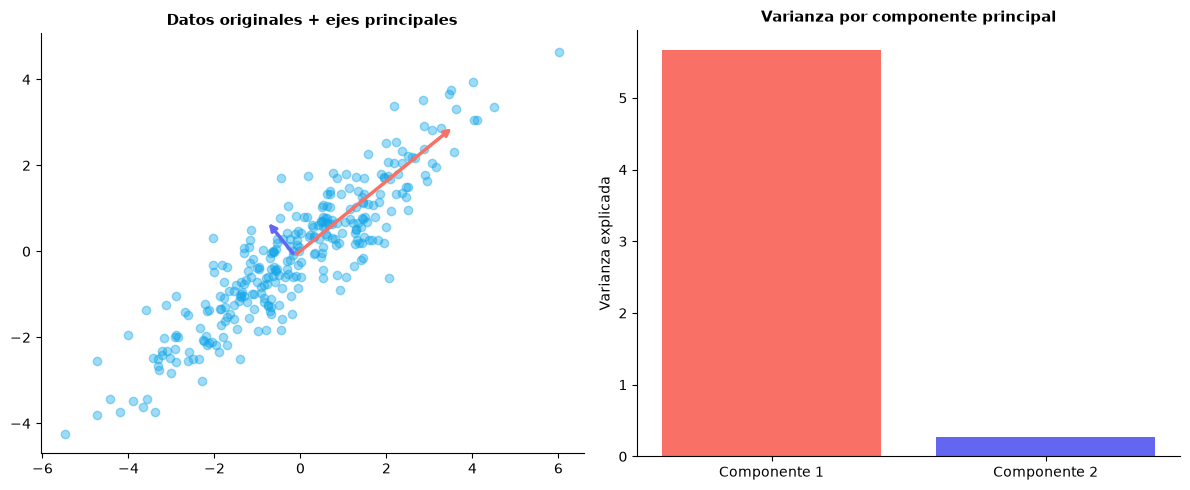

La componente 1 (flecha coral) explica el 95.5% de la varianza total.
La componente 2 (flecha índigo) explica el 4.5% restante.


In [8]:
from sklearn.decomposition import PCA

# 1. Datos sintéticos correlacionados (una nube de puntos alargada y rotada)
media = [0, 0]
covarianza = [[3.0, 2.2], [2.2, 2.0]]
datos = np.random.multivariate_normal(media, covarianza, size=300)

# 2. Ajustar PCA
pca = PCA(n_components=2)
pca.fit(datos)
componentes = pca.components_
varianza_explicada = pca.explained_variance_

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel izquierdo: los datos originales y sus dos ejes principales
axes[0].scatter(datos[:, 0], datos[:, 1], alpha=0.4, color=AZUL)
centro_datos = datos.mean(axis=0)
colores_ejes = [CORAL, INDIGO]
for i in range(2):
    direccion = componentes[i] * np.sqrt(varianza_explicada[i]) * 2
    axes[0].annotate(
        "", xy=centro_datos + direccion, xytext=centro_datos,
        arrowprops=dict(arrowstyle="->", color=colores_ejes[i], linewidth=2.5),
    )
axes[0].set_aspect("equal")
estilizar(axes[0], "Datos originales + ejes principales")

# Panel derecho: cuánta varianza captura cada componente
axes[1].bar(["Componente 1", "Componente 2"], varianza_explicada, color=[CORAL, INDIGO])
axes[1].set_ylabel("Varianza explicada")
estilizar(axes[1], "Varianza por componente principal")

plt.tight_layout()
plt.show()

proporcion = varianza_explicada / varianza_explicada.sum()
print(f"La componente 1 (flecha coral) explica el {proporcion[0]:.1%} de la varianza total.")
print(f"La componente 2 (flecha índigo) explica el {proporcion[1]:.1%} restante.")

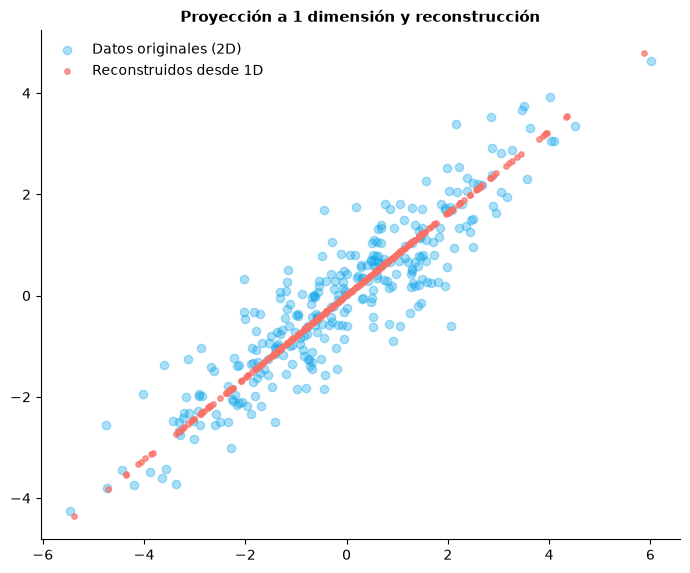

Con 1 sola dimensión se conserva el 95.5% de la varianza.
Error cuadrático medio de reconstrucción: 0.266


In [9]:
# Reducción de dimensionalidad real: proyectar a 1 sola componente y reconstruir

pca_1d = PCA(n_components=1)
datos_reducidos = pca_1d.fit_transform(datos)
datos_reconstruidos = pca_1d.inverse_transform(datos_reducidos)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(datos[:, 0], datos[:, 1], alpha=0.35, color=AZUL, label="Datos originales (2D)")
ax.scatter(datos_reconstruidos[:, 0], datos_reconstruidos[:, 1], alpha=0.7, color=CORAL, s=15,
           label="Reconstruidos desde 1D")
ax.set_aspect("equal")
ax.legend(frameon=False)
estilizar(ax, "Proyección a 1 dimensión y reconstrucción")
plt.tight_layout()
plt.show()

error_reconstruccion = np.mean(np.sum((datos - datos_reconstruidos) ** 2, axis=1))
print(f"Con 1 sola dimensión se conserva el {pca_1d.explained_variance_ratio_[0]:.1%} de la varianza.")
print(f"Error cuadrático medio de reconstrucción: {error_reconstruccion:.3f}")

Los puntos reconstruidos caen todos sobre la línea de la primera componente principal: al quedarse con una sola dimensión se pierde la variación en la dirección perpendicular (la segunda componente), pero se conserva la mayor parte de la información porque esa dirección tenía la mayor varianza original.

---

<a id="bayes"></a>

# <span style="color:#F97066;">4. Teorema de Bayes y Clasificador Naïve Bayes</span>

El teorema de Bayes describe cómo actualizar la probabilidad de un evento a partir de nueva evidencia:

$$\underbrace{P(A|B)}_{posterior} = \frac{\overbrace{P(B|A)}^{verosimilitud} \times \overbrace{P(A)}^{prior}}{\underbrace{P(B)}_{evidencia}}$$

$P(A)$ es la creencia inicial (*prior*); $P(A|B)$ es la creencia actualizada tras observar $B$ (*posterior*) — generalmente una mejor estimación que $P(A)$ sola. Este mismo teorema se trabajó en profundidad, con la paradoja de las pruebas médicas, en <code>Unidad 3/1-AI-fundamentals/3-teorema-bayes.ipynb</code>.

In [10]:
# Ejemplo clásico: humo y fuego
p_fuego = 0.01          # P(F): probabilidad de que haya un incendio
p_humo = 0.10           # P(S): probabilidad de ver humo
p_humo_dado_fuego = 0.90  # P(S|F): si hay fuego, qué tan probable es ver humo

# Teorema de Bayes: P(F|S) = P(S|F) * P(F) / P(S)
p_fuego_dado_humo = (p_humo_dado_fuego * p_fuego) / p_humo

print(f"P(Fuego)          = {p_fuego:.0%}   (creencia previa)")
print(f"P(Humo)           = {p_humo:.0%}")
print(f"P(Humo | Fuego)   = {p_humo_dado_fuego:.0%}")
print(f"P(Fuego | Humo)   = {p_fuego_dado_humo:.0%}   (creencia actualizada al ver humo)")

P(Fuego)          = 1%   (creencia previa)
P(Humo)           = 10%
P(Humo | Fuego)   = 90%
P(Fuego | Humo)   = 9%   (creencia actualizada al ver humo)


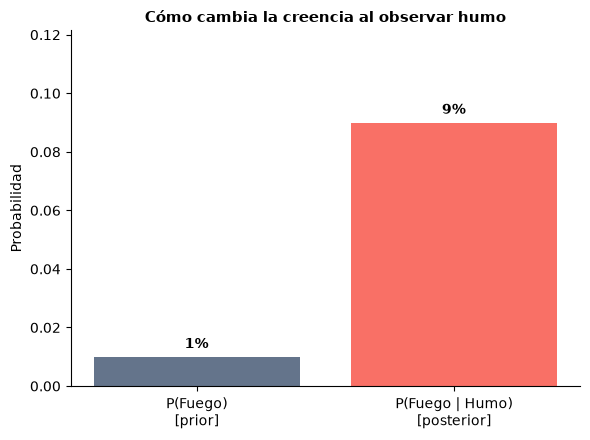

In [11]:
fig, ax = plt.subplots(figsize=(6, 4.5))
barras = ax.bar(
    ["P(Fuego)\n[prior]", "P(Fuego | Humo)\n[posterior]"],
    [p_fuego, p_fuego_dado_humo],
    color=[GRIS, CORAL],
)
for barra in barras:
    altura = barra.get_height()
    ax.text(barra.get_x() + barra.get_width() / 2, altura + 0.003, f"{altura:.0%}",
            ha="center", fontweight="bold")
ax.set_ylim(0, p_fuego_dado_humo * 1.35)
ax.set_ylabel("Probabilidad")
estilizar(ax, "Cómo cambia la creencia al observar humo")
plt.tight_layout()
plt.show()

Ver humo multiplica por 9 la probabilidad estimada de que haya fuego (de 1% a 9%) — sigue siendo poco probable en términos absolutos, pero la evidencia sí actualizó la creencia de forma significativa.

<span style="color:#F97066;">MAP vs. MLE</span>

- **Máxima verosimilitud (MLE)**: estima $\hat y = \arg\max_y \prod_i P(x_i|y)$ — no asume ningún conocimiento previo sobre $y$.
- **Máximo a posteriori (MAP)**: estima $\hat y = \arg\max_y\; P(y) \prod_i P(x_i|y)$ — incorpora una creencia previa $P(y)$.
- MLE es un caso particular de MAP cuando el prior es uniforme (todos los valores son igualmente probables).

**Clasificador Naïve Bayes** es una aplicación directa de MAP: asume que las características $(x_1, x_2, \dots)$ son condicionalmente independientes entre sí dado $y$ (de ahí "ingenuo"), lo que simplifica $P(x_1,x_2,\dots|y) = \prod_i P(x_i|y)$, y clasifica eligiendo la clase que maximiza $P(y)\prod_i P(x_i|y)$.

---

<a id="regresion"></a>

# <span style="color:#F97066;">5. Análisis de Regresión</span>

El análisis de regresión ajusta una función $f(\cdot)$ a un conjunto de puntos $y_i = f(x_i)$, minimizando alguna función de error. Distintas combinaciones de qué función se ajusta y qué error se minimiza dan lugar a distintos tipos de regresión:

| Tipo | Ajusta | Función de error |
|---|---|---|
| **Lineal** | Una línea | Suma de error cuadrático medio |
| **Polinomial** | Un polinomio de grado $k$ | Suma de error cuadrático medio |
| **Ridge** | Línea/polinomio | Error cuadrático + norma L2 de los coeficientes |
| **LASSO** | Línea/polinomio | Error cuadrático + norma L1 de los coeficientes |
| **Logística** | Línea/polinomio + sigmoide | Entropía cruzada binaria |

Ridge y LASSO se profundizan en la siguiente sección (Regularización). Aquí se comparan visualmente sobre los mismos datos.

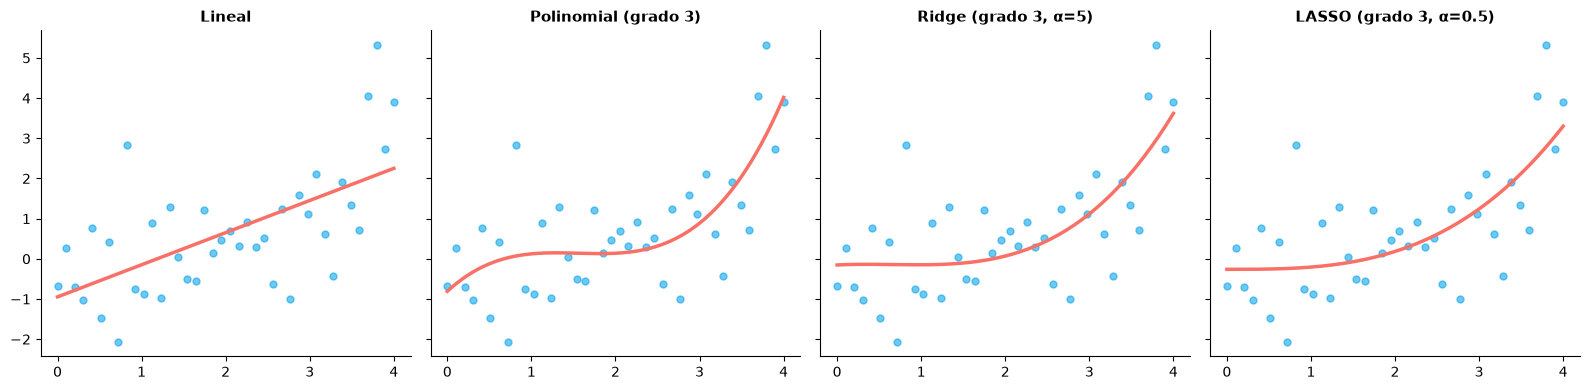

In [12]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# 1. Datos sintéticos no lineales
x = np.linspace(0, 4, 40)
y = 0.5 * x**2 - x + np.random.normal(0, 1.2, size=x.shape)
X = x.reshape(-1, 1)
x_curva = np.linspace(0, 4, 200).reshape(-1, 1)

modelos = {
    "Lineal": LinearRegression(),
    "Polinomial (grado 3)": make_pipeline(PolynomialFeatures(3), LinearRegression()),
    "Ridge (grado 3, α=5)": make_pipeline(PolynomialFeatures(3), Ridge(alpha=5)),
    "LASSO (grado 3, α=0.5)": make_pipeline(PolynomialFeatures(3), Lasso(alpha=0.5)),
}

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, (nombre, modelo) in zip(axes, modelos.items()):
    modelo.fit(X, y)
    ax.scatter(x, y, color=AZUL, alpha=0.6, s=25)
    ax.plot(x_curva, modelo.predict(x_curva), color=CORAL, linewidth=2.5)
    estilizar(ax, nombre)

plt.tight_layout()
plt.show()

Las cuatro regresiones parten del mismo tipo de ajuste polinomial (salvo la primera, lineal), pero Ridge y LASSO producen curvas algo más suaves — el efecto de penalizar coeficientes grandes se explora en detalle en la siguiente sección.

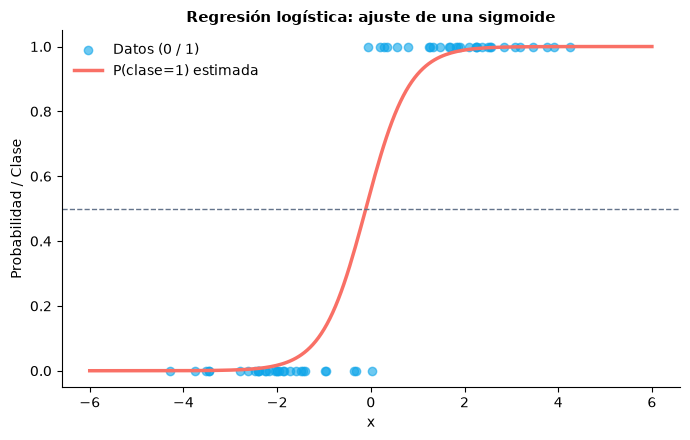

In [13]:
from sklearn.linear_model import LogisticRegression

# Regresión logística: ajusta una sigmoide para clasificación binaria
np.random.seed(7)
x_clas = np.concatenate([np.random.normal(-2, 1, 30), np.random.normal(2, 1, 30)])
y_clas = np.concatenate([np.zeros(30), np.ones(30)])

modelo_logistico = LogisticRegression().fit(x_clas.reshape(-1, 1), y_clas)

x_curva_clas = np.linspace(-6, 6, 200).reshape(-1, 1)
probabilidades = modelo_logistico.predict_proba(x_curva_clas)[:, 1]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.scatter(x_clas, y_clas, color=AZUL, alpha=0.6, label="Datos (0 / 1)")
ax.plot(x_curva_clas, probabilidades, color=CORAL, linewidth=2.5, label="P(clase=1) estimada")
ax.axhline(0.5, color=GRIS, linestyle="--", linewidth=1)
ax.set_xlabel("x")
ax.set_ylabel("Probabilidad / Clase")
ax.legend(frameon=False)
estilizar(ax, "Regresión logística: ajuste de una sigmoide")
plt.tight_layout()
plt.show()

---

<a id="regularizacion"></a>

# <span style="color:#F97066;">6. Regularización en ML</span>

La regularización es un conjunto de técnicas para reducir el sobreajuste — es decir, para reducir la **varianza** del modelo (sección 1) a cambio de un poco más de sesgo.

**Modificar la función de pérdida:**

$$loss_{L2} = error(y,\hat y) + \lambda\sum_j \beta_j^2 \qquad\qquad loss_{L1} = error(y,\hat y) + \lambda\sum_j |\beta_j|$$

- **L2 (Ridge)**: penaliza el cuadrado de los coeficientes — los reduce de forma suave, pero rara vez los lleva exactamente a cero.
- **L1 (LASSO)**: penaliza el valor absoluto de los coeficientes — introduce **sparsity** (dispersión): fuerza a que muchos coeficientes sean exactamente cero, actuando como una selección automática de variables.
- En ambos casos, a mayor $\lambda$, mayor sesgo y menor varianza.

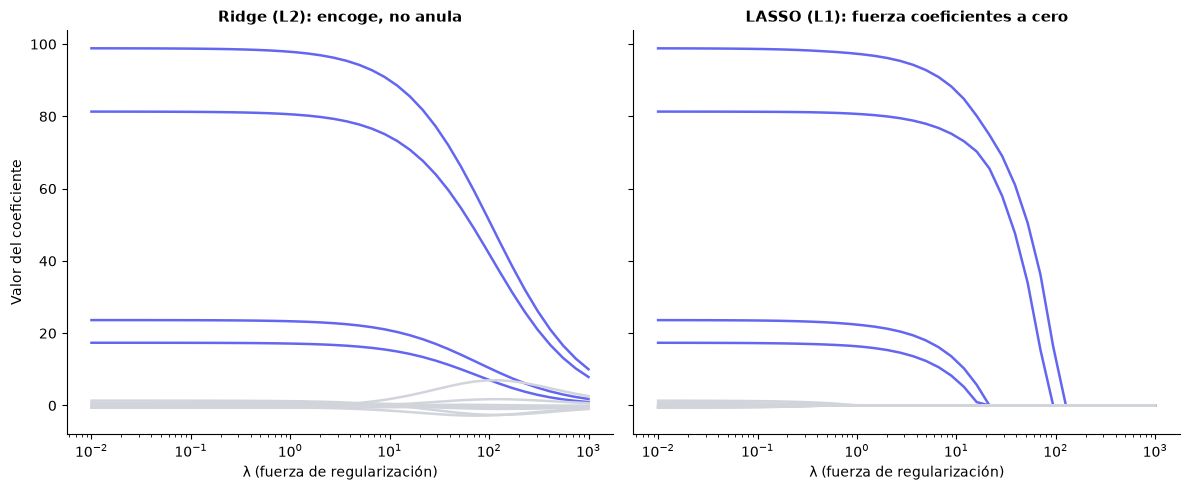

Líneas índigo = variables realmente informativas · líneas grises = variables irrelevantes (ruido)


In [14]:
from sklearn.datasets import make_regression

# 1. Datos con muchas variables, pero solo algunas realmente relevantes
X_reg, y_reg, coeficientes_reales = make_regression(
    n_samples=100, n_features=12, n_informative=4, noise=8,
    coef=True, random_state=1,
)

alphas = np.logspace(-2, 3, 40)
coeficientes_ridge = []
coeficientes_lasso = []

for alpha in alphas:
    coeficientes_ridge.append(Ridge(alpha=alpha).fit(X_reg, y_reg).coef_)
    coeficientes_lasso.append(Lasso(alpha=alpha, max_iter=20000).fit(X_reg, y_reg).coef_)

coeficientes_ridge = np.array(coeficientes_ridge)
coeficientes_lasso = np.array(coeficientes_lasso)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for j in range(X_reg.shape[1]):
    color = INDIGO if coeficientes_reales[j] != 0 else "#D1D5DB"
    axes[0].plot(alphas, coeficientes_ridge[:, j], color=color, linewidth=1.8)
    axes[1].plot(alphas, coeficientes_lasso[:, j], color=color, linewidth=1.8)

for ax, titulo in zip(axes, ["Ridge (L2): encoge, no anula", "LASSO (L1): fuerza coeficientes a cero"]):
    ax.set_xscale("log")
    ax.set_xlabel("λ (fuerza de regularización)")
    estilizar(ax, titulo)
axes[0].set_ylabel("Valor del coeficiente")

plt.tight_layout()
plt.show()

print("Líneas índigo = variables realmente informativas · líneas grises = variables irrelevantes (ruido)")

A medida que $\lambda$ crece, ambos modelos reducen la magnitud de sus coeficientes. La diferencia clave está en las variables irrelevantes (líneas grises): en Ridge se acercan a cero pero casi nunca lo tocan exactamente; en LASSO, varias llegan a **exactamente cero** y se quedan ahí — eliminando esas variables del modelo por completo.

<span style="color:#F97066;">Validación cruzada en k particiones (k-fold)</span>

Otra forma de regularizar es cambiar cómo se muestrean los datos: dividirlos en $k$ grupos, entrenar con $k-1$ y evaluar con el grupo restante, repitiendo hasta que cada grupo haya servido una vez como prueba.

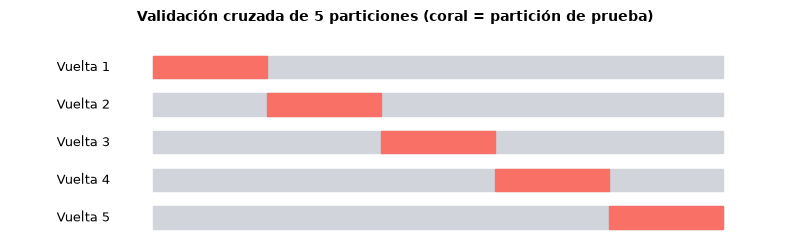

Vuelta 1: R² = 0.995
Vuelta 2: R² = 0.998
Vuelta 3: R² = 0.993
Vuelta 4: R² = 0.990
Vuelta 5: R² = 0.997

R² promedio: 0.995 (± 0.003)


In [15]:
from sklearn.model_selection import cross_val_score, KFold

k = 5
validador = KFold(n_splits=k, shuffle=True, random_state=0)
puntajes = cross_val_score(Ridge(alpha=1.0), X_reg, y_reg, cv=validador, scoring="r2")

fig, ax = plt.subplots(figsize=(8, 2.6))
alto = 0.6
for i in range(k):
    inicio_prueba = i * (20 / k)
    ax.add_patch(mpatches.Rectangle((0, k - i - 1), 20, alto, color="#D1D5DB"))
    ax.add_patch(mpatches.Rectangle((inicio_prueba, k - i - 1), 20 / k, alto, color=CORAL))
    ax.text(-1.5, k - i - 1 + alto / 2, f"Vuelta {i+1}", ha="right", va="center", fontsize=9)

ax.set_xlim(-5, 22)
ax.set_ylim(-0.3, k + 0.3)
ax.axis("off")
ax.set_title(f"Validación cruzada de {k} particiones (coral = partición de prueba)", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()

for i, puntaje in enumerate(puntajes, 1):
    print(f"Vuelta {i}: R² = {puntaje:.3f}")
print(f"\nR² promedio: {puntajes.mean():.3f} (± {puntajes.std():.3f})")

<span style="color:#F97066;">Dropout</span>

En redes neuronales, el **dropout** desactiva aleatoriamente un porcentaje de las conexiones entre capas en cada iteración de entrenamiento, forzando a la red a no depender demasiado de ninguna neurona en particular — ya se usó en la práctica en <code>Unidad 4/3-redes-convolucionales.ipynb</code>.

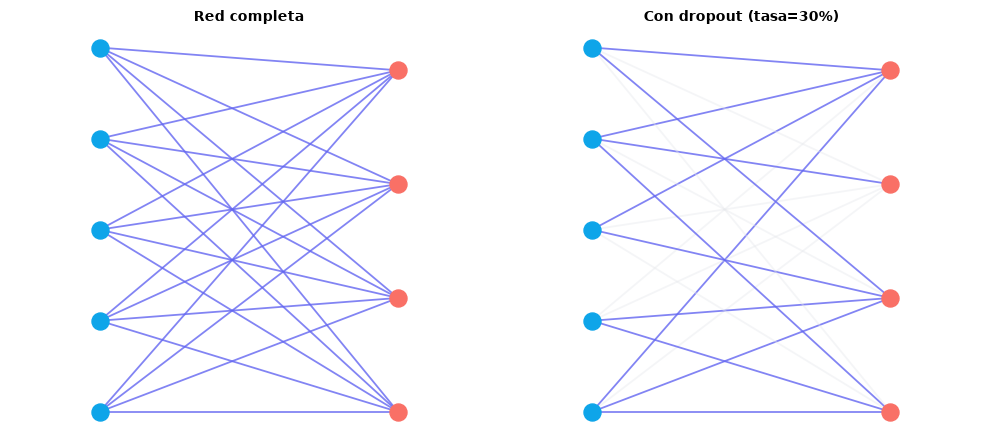

Conexiones activas: 12/20 (60%)


In [16]:
# Simulación de una capa con dropout: se genera una máscara aleatoria de conexiones activas

np.random.seed(3)
n_entrada, n_salida = 5, 4
tasa_dropout = 0.3

posiciones_entrada = [(0, i) for i in range(n_entrada)]
posiciones_salida = [(1, i * n_entrada / n_salida) for i in range(n_salida)]

mascara_activa = np.random.rand(n_entrada, n_salida) > tasa_dropout

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))
for ax, mostrar_dropout, titulo in zip(
    axes, [False, True], ["Red completa", f"Con dropout (tasa={tasa_dropout:.0%})"]
):
    for i, (x0, y0) in enumerate(posiciones_entrada):
        for j, (x1, y1) in enumerate(posiciones_salida):
            activa = mascara_activa[i, j] or not mostrar_dropout
            color = INDIGO if activa else "#E5E7EB"
            alpha = 0.8 if activa else 0.4
            ax.plot([x0, x1], [y0, y1], color=color, alpha=alpha, linewidth=1.3, zorder=1)
    for x0, y0 in posiciones_entrada:
        ax.scatter([x0], [y0], color=AZUL, s=150, zorder=2)
    for x1, y1 in posiciones_salida:
        ax.scatter([x1], [y1], color=CORAL, s=150, zorder=2)
    ax.set_xlim(-0.3, 1.3)
    ax.axis("off")
    ax.set_title(titulo, fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

conexiones_totales = n_entrada * n_salida
conexiones_activas = mascara_activa.sum()
print(f"Conexiones activas: {conexiones_activas}/{conexiones_totales} ({conexiones_activas/conexiones_totales:.0%})")

---

<a id="cnn-bloques"></a>

# <span style="color:#F97066;">7. Redes Neuronales Convolucionales: Bloques Básicos</span>

Una CNN se construye combinando un conjunto reducido de bloques, cada uno con un propósito distinto — ya trabajados en la práctica en <code>Unidad 4/3-redes-convolucionales.ipynb</code>:

| Bloque | Tipo | Propósito |
|---|---|---|
| **Convolucional** | Entrenable | Detecta patrones locales (bordes, texturas) mediante un kernel que se desliza sobre la entrada |
| **Totalmente conectada (Fully Connected)** | Entrenable | Combina linealmente todas las entradas: $y = \sum_i w_i x_i + b$ |
| **Pooling (Max/Average)** | No entrenable | Reduce el tamaño espacial del mapa de características |
| **Normalización (Batch Norm)** | Entrenable | Estabiliza la escala de las activaciones antes de la función de activación |
| **Activación** | No entrenable | Introduce no-linealidad (ReLU, sigmoide, tanh, …) |
| **Función de pérdida** | — | Cuantifica qué tan lejos está la predicción de la etiqueta real |

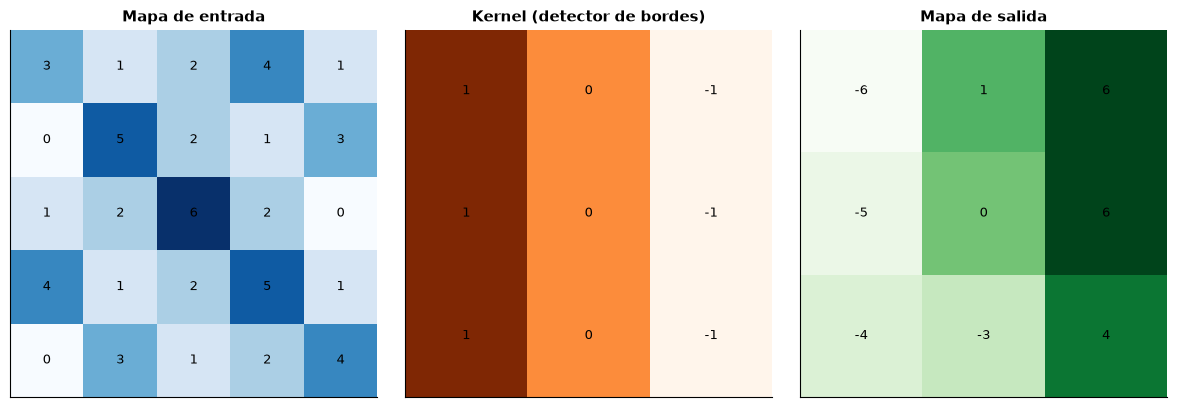

In [17]:
# La operación de convolución, paso a paso, sobre una entrada pequeña

entrada = np.array([
    [3, 1, 2, 4, 1],
    [0, 5, 2, 1, 3],
    [1, 2, 6, 2, 0],
    [4, 1, 2, 5, 1],
    [0, 3, 1, 2, 4],
], dtype=float)

kernel = np.array([
    [1, 0, -1],
    [1, 0, -1],
    [1, 0, -1],
], dtype=float)  # detector simple de bordes verticales

alto_k, ancho_k = kernel.shape
alto_salida = entrada.shape[0] - alto_k + 1
ancho_salida = entrada.shape[1] - ancho_k + 1
salida = np.zeros((alto_salida, ancho_salida))

for i in range(alto_salida):
    for j in range(ancho_salida):
        region = entrada[i:i + alto_k, j:j + ancho_k]
        salida[i, j] = np.sum(region * kernel)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, matriz, titulo, cmap in zip(
    axes, [entrada, kernel, salida],
    ["Mapa de entrada", "Kernel (detector de bordes)", "Mapa de salida"],
    ["Blues", "Oranges", "Greens"],
):
    ax.imshow(matriz, cmap=cmap)
    for (i, j), valor in np.ndenumerate(matriz):
        ax.text(j, i, f"{valor:g}", ha="center", va="center", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    estilizar(ax, titulo)

plt.tight_layout()
plt.show()

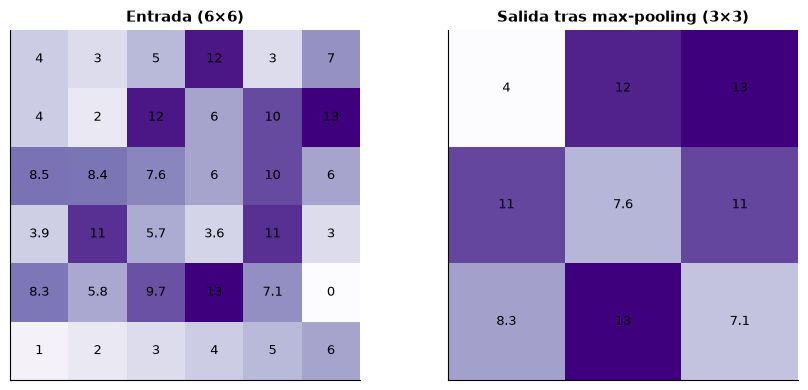

In [18]:
# Max pooling 2x2 con stride 2, sobre un mapa de activación de ejemplo

mapa = np.array([
    [4, 3, 5, 12, 3, 7],
    [4, 2, 12, 6, 10, 13],
    [8.5, 8.4, 7.6, 6, 10, 6],
    [3.9, 11, 5.7, 3.6, 11, 3],
    [8.3, 5.8, 9.7, 13, 7.1, 0],
    [1, 2, 3, 4, 5, 6],
])

tam_ventana, paso = 2, 2
filas_salida = mapa.shape[0] // paso
columnas_salida = mapa.shape[1] // paso
mapa_reducido = np.zeros((filas_salida, columnas_salida))

for i in range(filas_salida):
    for j in range(columnas_salida):
        ventana = mapa[i*paso:i*paso+tam_ventana, j*paso:j*paso+tam_ventana]
        mapa_reducido[i, j] = ventana.max()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, matriz, titulo in zip(axes, [mapa, mapa_reducido], ["Entrada (6×6)", "Salida tras max-pooling (3×3)"]):
    ax.imshow(matriz, cmap="Purples")
    for (i, j), valor in np.ndenumerate(matriz):
        ax.text(j, i, f"{valor:g}", ha="center", va="center", fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
    estilizar(ax, titulo)
plt.tight_layout()
plt.show()

Max-pooling no tiene parámetros entrenables: simplemente conserva el valor máximo de cada ventana, reduciendo el tamaño espacial del mapa (aquí, de 6×6 a 3×3) y con ello el número de cálculos de las capas siguientes.

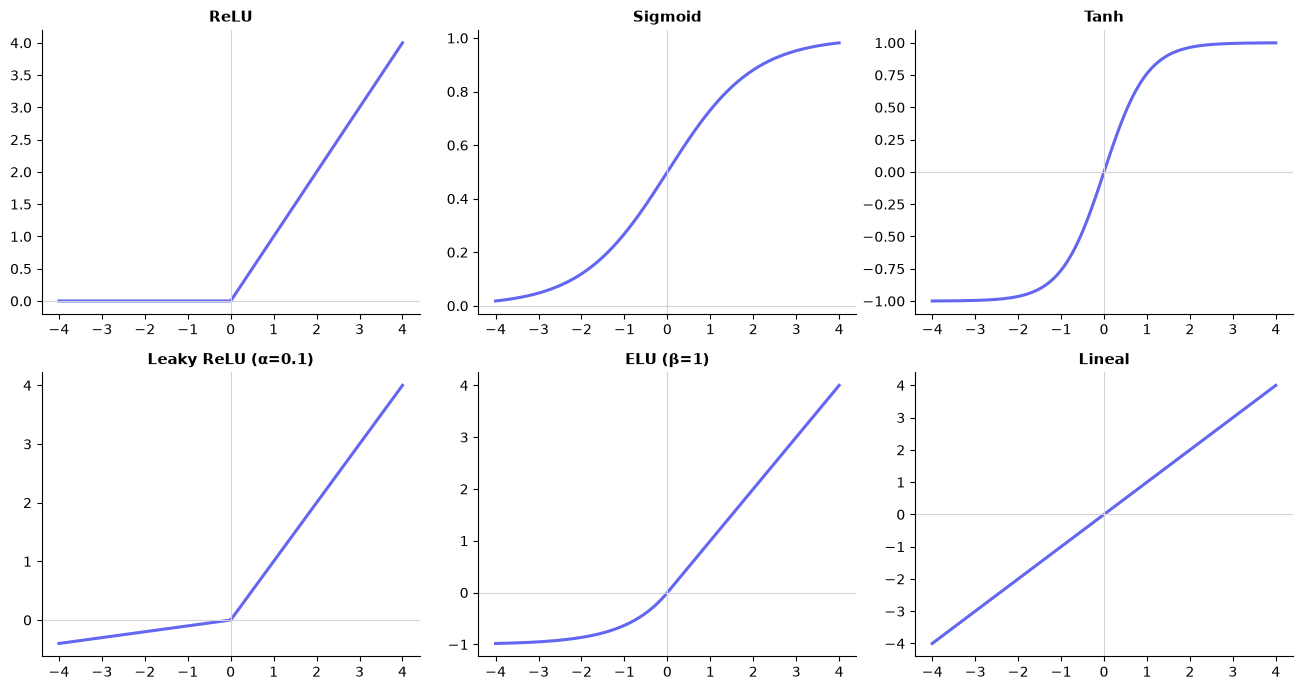

In [19]:
# Funciones de activación más comunes

x = np.linspace(-4, 4, 200)
activaciones = {
    "ReLU": np.maximum(0, x),
    "Sigmoid": 1 / (1 + np.exp(-x)),
    "Tanh": np.tanh(x),
    "Leaky ReLU (α=0.1)": np.where(x > 0, x, 0.1 * x),
    "ELU (β=1)": np.where(x > 0, x, np.exp(x) - 1),
    "Lineal": x,
}

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (nombre, valores) in zip(axes.flat, activaciones.items()):
    ax.plot(x, valores, color=INDIGO, linewidth=2.2)
    ax.axhline(0, color="#D1D5DB", linewidth=0.8)
    ax.axvline(0, color="#D1D5DB", linewidth=0.8)
    estilizar(ax, nombre)

plt.tight_layout()
plt.show()

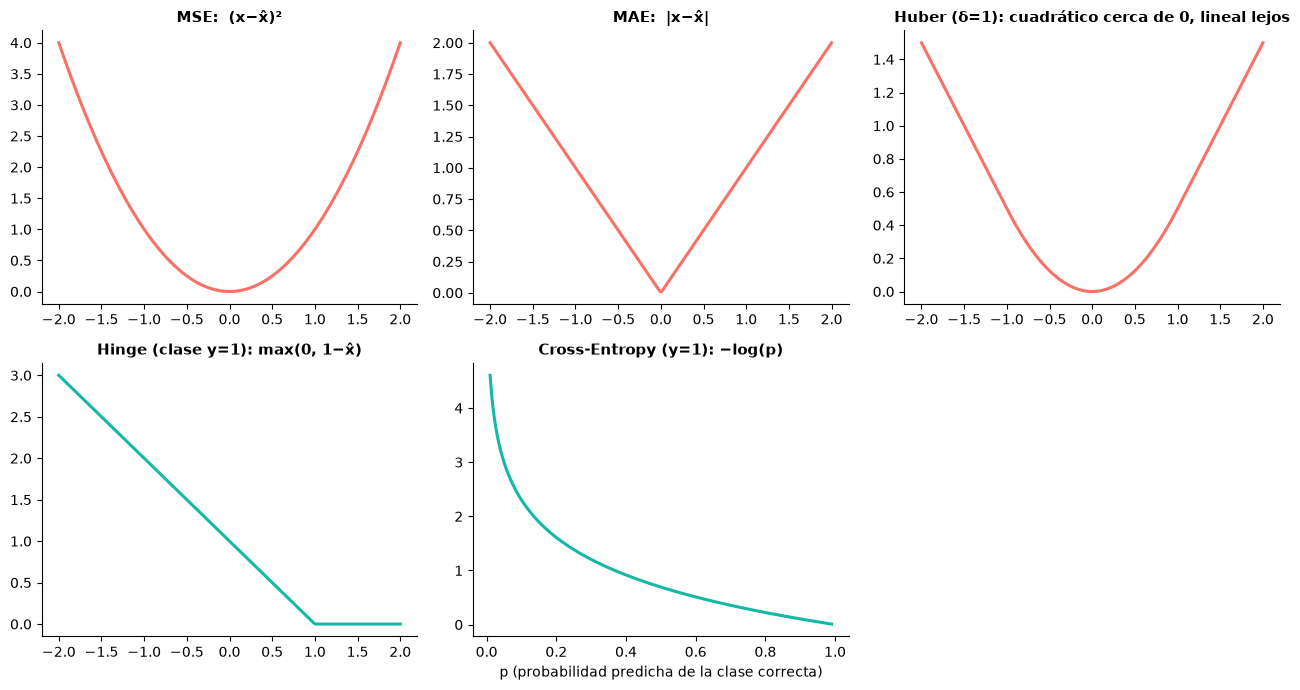

Regresión (arriba): MSE, MAE, Huber — penalizan la distancia entre valor real y predicho.
Clasificación (abajo): Hinge, Cross-Entropy — penalizan según la probabilidad/margen asignado a la clase correcta.


In [20]:
# Funciones de pérdida más comunes

x = np.linspace(-2, 2, 200)
p = np.linspace(0.01, 0.99, 200)

fig, axes = plt.subplots(2, 3, figsize=(13, 7))

axes[0, 0].plot(x, x**2, color=CORAL, linewidth=2.2)
estilizar(axes[0, 0], "MSE:  (x−x̂)²")

axes[0, 1].plot(x, np.abs(x), color=CORAL, linewidth=2.2)
estilizar(axes[0, 1], "MAE:  |x−x̂|")

delta = 1.0
huber = np.where(np.abs(x) < delta, 0.5 * x**2, delta * (np.abs(x) - 0.5 * delta))
axes[0, 2].plot(x, huber, color=CORAL, linewidth=2.2)
estilizar(axes[0, 2], "Huber (δ=1): cuadrático cerca de 0, lineal lejos")

hinge_pos = np.maximum(0, 1 - x)
axes[1, 0].plot(x, hinge_pos, color=TEAL, linewidth=2.2)
estilizar(axes[1, 0], "Hinge (clase y=1): max(0, 1−x̂)")

entropia_cruzada = -np.log(p)
axes[1, 1].plot(p, entropia_cruzada, color=TEAL, linewidth=2.2)
axes[1, 1].set_xlabel("p (probabilidad predicha de la clase correcta)")
estilizar(axes[1, 1], "Cross-Entropy (y=1): −log(p)")

axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

print("Regresión (arriba): MSE, MAE, Huber — penalizan la distancia entre valor real y predicho.")
print("Clasificación (abajo): Hinge, Cross-Entropy — penalizan según la probabilidad/margen asignado a la clase correcta.")

---

<a id="cnn-famosas"></a>

# <span style="color:#F97066;">8. CNNs Famosas</span>

**AlexNet (2012)** — Por qué: nació de la necesidad de mejorar los resultados del reto ImageNet. Qué: 5 capas convolucionales + 3 totalmente conectadas, activación ReLU. Cómo: usa aumento de datos para reducir el sobreajuste y normalización de respuesta local.

**VGGNet (2014)** — Por qué: nació de la necesidad de reducir el número de parámetros en las capas convolucionales y mejorar el tiempo de entrenamiento. Qué: existen varias variantes (VGG16, VGG19). Cómo: todos los kernels convolucionales son de 3×3 y los de max-pooling de 2×2 con stride 2.

**ResNet (2015)** — Por qué: las redes muy profundas tienen dificultad para aprender incluso una función tan simple como la identidad (problema del gradiente que desaparece). Qué: existen varias profundidades (ResNet50, ResNet101). Cómo: usa **conexiones de atajo (skip connections)** que le permiten a una capa aprender solo el residuo $f(x)$ sobre la entrada $x$, en vez de la transformación completa.

**Inception / GoogLeNet (2014)** — Por qué: los kernels grandes capturan features globales, los pequeños capturan features locales — en vez de elegir uno, Inception usa varios en paralelo. Qué: cada módulo Inception aplica, en paralelo, convoluciones 1×1, 3×3, 5×5 y max-pooling, y concatena sus salidas. Cómo: esto amplía el espacio de búsqueda de la red durante el entrenamiento.

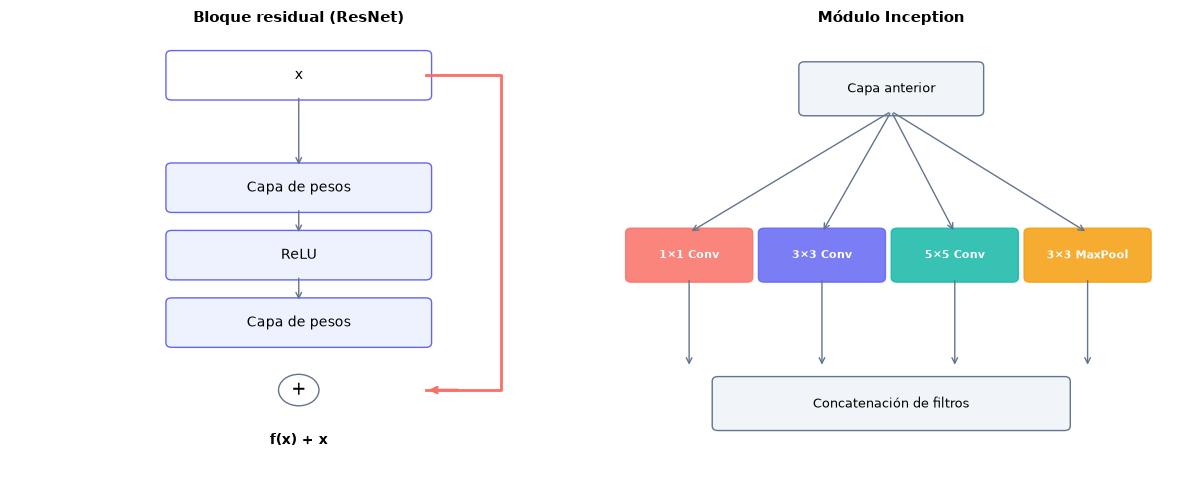

In [21]:
# Diagrama esquemático: bloque residual de ResNet vs. módulo Inception

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Bloque residual (ResNet) ---
ax = axes[0]
cajas = [("x", 0.5, 0.9), ("Capa de pesos", 0.5, 0.65), ("ReLU", 0.5, 0.5), ("Capa de pesos", 0.5, 0.35)]
for texto, cx, cy in cajas:
    color = AZUL if texto == "x" else INDIGO
    estilo_texto = "white" if texto != "x" else "black"
    facecolor = "white" if texto == "x" else "#EEF2FF"
    ax.add_patch(mpatches.FancyBboxPatch((cx - 0.22, cy - 0.045), 0.44, 0.09,
                                          boxstyle="round,pad=0.01", facecolor=facecolor, edgecolor=INDIGO))
    ax.text(cx, cy, texto, ha="center", va="center", fontsize=10)
for y0, y1 in [(0.855, 0.695), (0.605, 0.545), (0.455, 0.395)]:
    ax.annotate("", xy=(0.5, y1), xytext=(0.5, y0), arrowprops=dict(arrowstyle="->", color=GRIS))
# Atajo (skip connection)
ax.plot([0.72, 0.85, 0.85, 0.72], [0.9, 0.9, 0.2, 0.2], color=CORAL, linewidth=2)
ax.annotate("", xy=(0.72, 0.2), xytext=(0.78, 0.2), arrowprops=dict(arrowstyle="->", color=CORAL, linewidth=2))
ax.add_patch(mpatches.Circle((0.5, 0.2), 0.035, facecolor="white", edgecolor=GRIS))
ax.text(0.5, 0.2, "+", ha="center", va="center", fontsize=13)
ax.text(0.5, 0.08, "f(x) + x", ha="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
ax.set_title("Bloque residual (ResNet)", fontsize=11, fontweight="bold")

# --- Módulo Inception ---
ax = axes[1]
ax.add_patch(mpatches.FancyBboxPatch((0.35, 0.82), 0.3, 0.1, boxstyle="round,pad=0.01",
                                      facecolor="#F1F5F9", edgecolor=GRIS))
ax.text(0.5, 0.87, "Capa anterior", ha="center", va="center", fontsize=9)
ramas = ["1×1 Conv", "3×3 Conv", "5×5 Conv", "3×3 MaxPool"]
colores_ramas = [CORAL, INDIGO, TEAL, "#F59E0B"]
posiciones_x = [0.15, 0.38, 0.61, 0.84]
for x0, texto, color in zip(posiciones_x, ramas, colores_ramas):
    ax.add_patch(mpatches.FancyBboxPatch((x0 - 0.1, 0.45), 0.2, 0.1, boxstyle="round,pad=0.01",
                                          facecolor=color, edgecolor=color, alpha=0.85))
    ax.text(x0, 0.5, texto, ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    ax.annotate("", xy=(x0, 0.55), xytext=(0.5, 0.82), arrowprops=dict(arrowstyle="->", color=GRIS, linewidth=1))
    ax.annotate("", xy=(x0, 0.25), xytext=(x0, 0.45), arrowprops=dict(arrowstyle="->", color=GRIS, linewidth=1))
ax.add_patch(mpatches.FancyBboxPatch((0.2, 0.12), 0.6, 0.1, boxstyle="round,pad=0.01",
                                      facecolor="#F1F5F9", edgecolor=GRIS))
ax.text(0.5, 0.17, "Concatenación de filtros", ha="center", va="center", fontsize=9)
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.axis("off")
ax.set_title("Módulo Inception", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

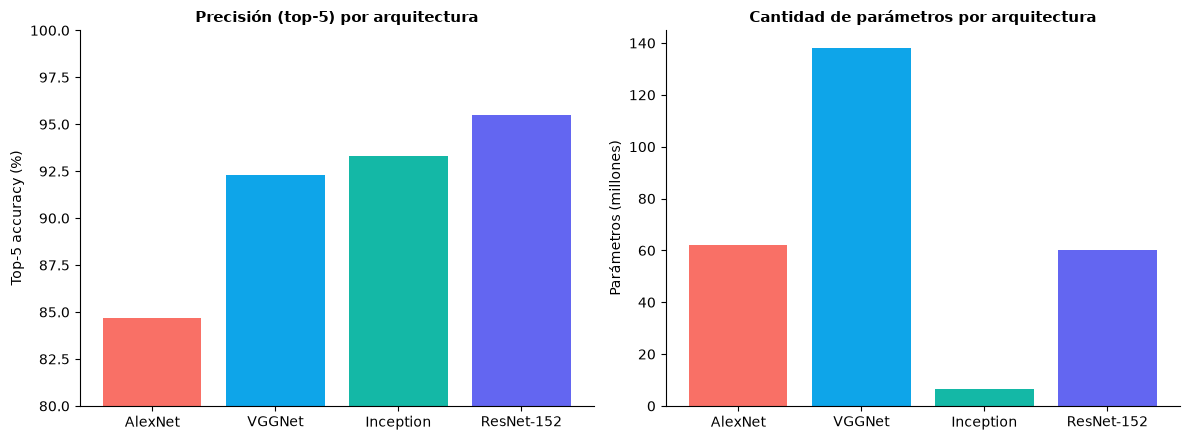

Nota: Inception logra una precisión competitiva con muchísimos menos parámetros que VGGNet —
consecuencia directa de reemplazar capas totalmente conectadas gigantes por módulos más eficientes.


In [22]:
# Comparación de las 4 arquitecturas (datos publicados, tomados del cheat sheet original)

redes = ["AlexNet", "VGGNet", "Inception", "ResNet-152"]
anio = [2012, 2014, 2014, 2015]
top5_precision = [84.70, 92.30, 93.30, 95.51]
parametros_millones = [62, 138, 6.4, 60.3]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(redes, top5_precision, color=[CORAL, AZUL, TEAL, INDIGO])
axes[0].set_ylim(80, 100)
axes[0].set_ylabel("Top-5 accuracy (%)")
estilizar(axes[0], "Precisión (top-5) por arquitectura")

axes[1].bar(redes, parametros_millones, color=[CORAL, AZUL, TEAL, INDIGO])
axes[1].set_ylabel("Parámetros (millones)")
estilizar(axes[1], "Cantidad de parámetros por arquitectura")

plt.tight_layout()
plt.show()

print("Nota: Inception logra una precisión competitiva con muchísimos menos parámetros que VGGNet —")
print("consecuencia directa de reemplazar capas totalmente conectadas gigantes por módulos más eficientes.")

El salto de precisión de AlexNet (2012) a ResNet-152 (2015) ocurre en apenas 3 años, y no es solo cuestión de "redes más grandes": Inception logra una precisión mayor que VGGNet con **20 veces menos parámetros**, gracias a un diseño más eficiente — la misma idea de "arquitectura sobre fuerza bruta" que reaparece en `MobileNetV2`, usado en <code>Unidad 4/3-redes-convolucionales.ipynb</code> para transferencia de aprendizaje.

---

<a id="ensamble"></a>

# <span style="color:#F97066;">9. Aprendizaje por Ensamble</span>

**Ensamble** = combinar varios modelos débiles en un solo modelo predictivo, para reducir sesgo, varianza, y/o mejorar la exactitud ("la sabiduría de las masas"). Ya se trabajó en profundidad en <code>Unidad 3/5-modelos-ensamble.ipynb</code>; aquí se resume el panorama completo.

| | Bagging | Boosting | Stacking |
|---|---|---|---|
| **Se enfoca en** | Reducir varianza | Reducir sesgo | Mejorar exactitud |
| **Los modelos débiles son** | Homogéneos (mismo tipo) | Homogéneos (mismo tipo) | Heterogéneos (tipos distintos) |
| **Se combinan por** | Votación simple | Votación ponderada | Votación aprendida (meta-modelo) |
| **Entrenamiento** | En paralelo, subconjuntos distintos | Secuencial, ajustando pesos de errores | En paralelo + meta-modelo entrenado sobre las salidas |

- **Bagging**: entrena $N$ modelos del mismo tipo con subconjuntos aleatorios (con reemplazo) del dataset, en paralelo. La predicción final es un voto simple.
- **Boosting**: entrena $N$ modelos en secuencia; cada modelo nuevo se enfoca más en los puntos que el anterior clasificó mal. La predicción final es un voto ponderado según el error de cada modelo.
- **Stacking**: entrena varios modelos de tipos distintos y usa un meta-modelo que aprende a combinar sus predicciones.

In [23]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression as LogReg
from sklearn.svm import SVC

# 1. Dataset sintético de clasificación con algo de ruido
X_ens, y_ens = make_classification(
    n_samples=400, n_features=10, n_informative=5, n_redundant=2,
    flip_y=0.08, random_state=0,
)

modelos_ensamble = {
    "Árbol único": DecisionTreeClassifier(max_depth=4, random_state=0),
    "Bagging (100 árboles)": BaggingClassifier(
        DecisionTreeClassifier(max_depth=4), n_estimators=100, random_state=0
    ),
    "Boosting - AdaBoost": AdaBoostClassifier(n_estimators=100, random_state=0),
    "Stacking (árbol+logística+SVM)": StackingClassifier(
        estimators=[
            ("arbol", DecisionTreeClassifier(max_depth=4, random_state=0)),
            ("logistica", LogReg(max_iter=1000)),
            ("svm", SVC(probability=True)),
        ],
        final_estimator=LogReg(),
    ),
}

# 2. Repetir el experimento con 15 particiones aleatorias distintas de train/test,
#    para poder medir no solo la exactitud promedio sino también su variabilidad
resultados = {nombre: [] for nombre in modelos_ensamble}
for semilla in range(15):
    X_tr, X_te, y_tr, y_te = train_test_split(X_ens, y_ens, test_size=0.3, random_state=semilla)
    for nombre, modelo in modelos_ensamble.items():
        modelo.fit(X_tr, y_tr)
        resultados[nombre].append(modelo.score(X_te, y_te))

for nombre, puntajes in resultados.items():
    print(f"{nombre:32s}: exactitud media = {np.mean(puntajes):.3f}  (desv. estándar = {np.std(puntajes):.3f})")

Árbol único                     : exactitud media = 0.859  (desv. estándar = 0.026)
Bagging (100 árboles)           : exactitud media = 0.876  (desv. estándar = 0.021)
Boosting - AdaBoost             : exactitud media = 0.856  (desv. estándar = 0.030)
Stacking (árbol+logística+SVM)  : exactitud media = 0.893  (desv. estándar = 0.018)


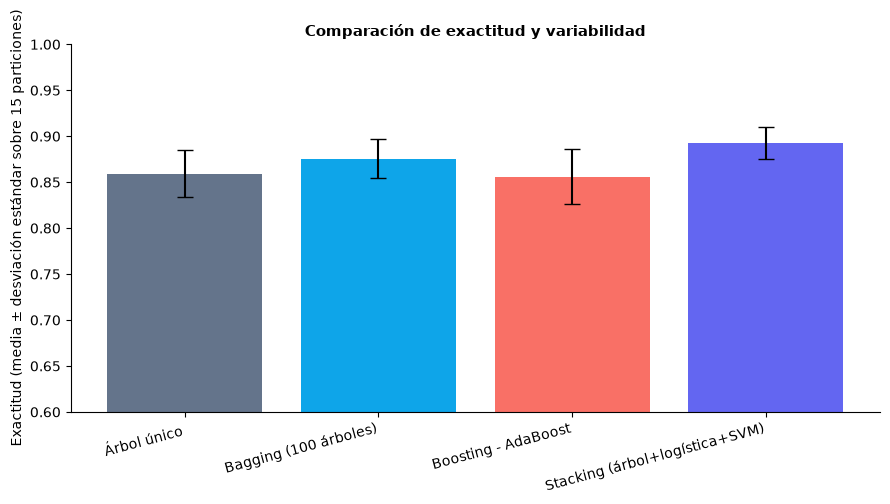

In [24]:
fig, ax = plt.subplots(figsize=(9, 5))
nombres = list(resultados.keys())
medias = [np.mean(resultados[n]) for n in nombres]
desviaciones = [np.std(resultados[n]) for n in nombres]
colores_barras = [GRIS, AZUL, CORAL, INDIGO]

ax.bar(nombres, medias, yerr=desviaciones, capsize=6, color=colores_barras)
ax.set_ylabel("Exactitud (media ± desviación estándar sobre 15 particiones)")
ax.set_ylim(0.6, 1.0)
plt.xticks(rotation=15, ha="right")
estilizar(ax, "Comparación de exactitud y variabilidad")
plt.tight_layout()
plt.show()

El árbol único tiene, de las cuatro opciones, la exactitud promedio más baja. Bagging sí reduce la variabilidad entre particiones frente al árbol único (0.021 vs. 0.026 de desviación estándar), el efecto esperado de promediar sobre 100 árboles entrenados con muestras distintas — aunque Boosting, en esta ejecución puntual, no logra reducirla (0.030). Stacking combina la mayor exactitud promedio con la menor variabilidad de las cuatro, a cambio de mayor costo computacional y menor interpretabilidad.

---

<a id="estructuras-datos"></a>

# <span style="color:#F97066;">10. Estructuras de Datos</span>

Los algoritmos de búsqueda de <code>Unidad 2/1_buscar-estados-ia.ipynb</code> (BFS, DFS, A*) se apoyan directamente en estas estructuras. Aquí se resumen con demostraciones ejecutables en Python.

<span style="color:#F97066;">Pila (Stack) — LIFO</span>

Último en entrar, primero en salir. `push()` agrega al tope, `pop()` remueve del tope. Un ejemplo cotidiano: una pila de platos.

In [25]:
pila = []

for valor in [12, 2, 0, 6]:
    pila.append(valor)  # push()
    print(f"push({valor}) → pila: {pila}")

print()
while pila:
    valor = pila.pop()  # pop()
    print(f"pop() → {valor}  | pila restante: {pila}")

push(12) → pila: [12]
push(2) → pila: [12, 2]
push(0) → pila: [12, 2, 0]
push(6) → pila: [12, 2, 0, 6]

pop() → 6  | pila restante: [12, 2, 0]
pop() → 0  | pila restante: [12, 2]
pop() → 2  | pila restante: [12]
pop() → 12  | pila restante: []


<span style="color:#F97066;">Cola (Queue) — FIFO</span>

Primero en entrar, primero en salir. `enqueue()` agrega al final, `dequeue()` remueve del frente — como una fila para pagar en una tienda. Esta es la estructura que usa BFS para explorar estados en orden de descubrimiento.

In [26]:
from collections import deque

cola = deque()

for valor in [12, 2, 0, 6]:
    cola.append(valor)  # enqueue()
    print(f"enqueue({valor}) → cola: {list(cola)}")

print()
while cola:
    valor = cola.popleft()  # dequeue()
    print(f"dequeue() → {valor}  | cola restante: {list(cola)}")

enqueue(12) → cola: [12]
enqueue(2) → cola: [12, 2]
enqueue(0) → cola: [12, 2, 0]
enqueue(6) → cola: [12, 2, 0, 6]

dequeue() → 12  | cola restante: [2, 0, 6]
dequeue() → 2  | cola restante: [0, 6]
dequeue() → 0  | cola restante: [6]
dequeue() → 6  | cola restante: []


<span style="color:#F97066;">Árbol (Tree) y Grafo (Graph)</span>

Un **árbol** mantiene una relación jerárquica (un nodo raíz, nodos padres e hijos, sin ciclos). Un **grafo** es más general: un par de conjuntos $(V, E)$ de vértices y aristas, que sí puede tener ciclos. **BFS** (recorrido por niveles, usando una cola) y **DFS** (recorrido en profundidad, usando una pila o recursión) son las dos formas estándar de recorrerlos — exactamente los algoritmos de <code>Unidad 2/1_buscar-estados-ia.ipynb</code>, aplicados aquí a un árbol simple.

In [27]:
# Árbol representado como diccionario de adyacencia (nodo → hijos)
arbol = {
    12: [2, 18],
    2: [6, 0],
    18: [6, 8],
    6: [],
    0: [3, 8],
    8: [],
    3: [],
}

def bfs(grafo, inicio):
    visitados, cola, orden = {inicio}, deque([inicio]), []
    while cola:
        nodo = cola.popleft()
        orden.append(nodo)
        for vecino in grafo[nodo]:
            if vecino not in visitados:
                visitados.add(vecino)
                cola.append(vecino)
    return orden

def dfs(grafo, inicio):
    visitados, pila, orden = set(), [inicio], []
    while pila:
        nodo = pila.pop()
        if nodo not in visitados:
            visitados.add(nodo)
            orden.append(nodo)
            for vecino in reversed(grafo[nodo]):
                if vecino not in visitados:
                    pila.append(vecino)
    return orden

print("Orden BFS (por niveles, con una cola):    ", bfs(arbol, 12))
print("Orden DFS (en profundidad, con una pila):", dfs(arbol, 12))

Orden BFS (por niveles, con una cola):     [12, 2, 18, 6, 0, 8, 3]
Orden DFS (en profundidad, con una pila): [12, 2, 6, 0, 3, 8, 18]


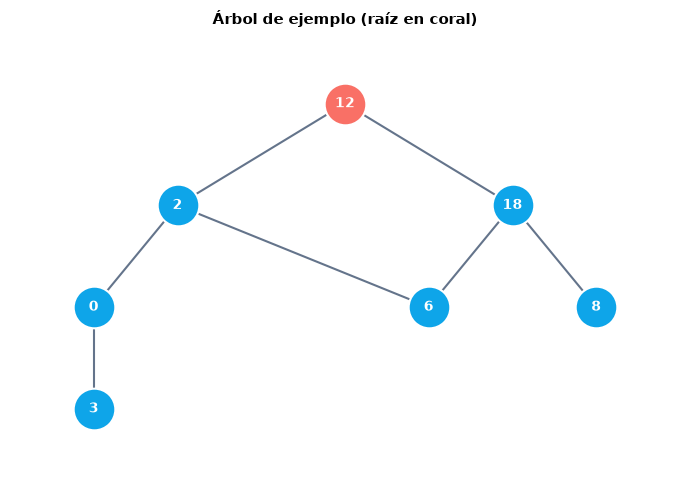

In [28]:
# Visualización del árbol usado en el recorrido anterior

posiciones = {12: (0, 2), 2: (-1.5, 1), 18: (1.5, 1), 6: (0.75, 0), 0: (-2.25, 0), 8: (2.25, 0), 3: (-2.25, -1)}
aristas = [(12, 2), (12, 18), (2, 6), (2, 0), (18, 6), (18, 8), (0, 3)]

fig, ax = plt.subplots(figsize=(7, 5))
for a, b in aristas:
    x0, y0 = posiciones[a]
    x1, y1 = posiciones[b]
    ax.plot([x0, x1], [y0, y1], color=GRIS, linewidth=1.5, zorder=1)
for nodo, (x, y) in posiciones.items():
    color = CORAL if nodo == 12 else AZUL
    ax.scatter([x], [y], s=900, color=color, zorder=2, edgecolor="white", linewidth=1.5)
    ax.text(x, y, str(nodo), ha="center", va="center", color="white", fontweight="bold", zorder=3)

ax.set_xlim(-3, 3)
ax.set_ylim(-1.7, 2.7)
ax.axis("off")
ax.set_title("Árbol de ejemplo (raíz en coral)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()

<span style="color:#F97066;">Tabla hash (HashTable)</span>

Crea pares (clave, valor) para acceder a un valor en tiempo constante, en promedio. Cada clave pasa por una **función hash** que decide en qué "cubeta" se guarda. Cuando dos claves distintas caen en la misma cubeta, ocurre una **colisión**.

In [29]:
def hash_simple(clave, n_cubetas):
    """Función hash de juguete: suma los códigos ASCII y toma el módulo."""
    return sum(ord(c) for c in clave) % n_cubetas


n_cubetas = 5
claves = ["gato", "perro", "pez", "loro", "ave", "oso"]
cubetas = {i: [] for i in range(n_cubetas)}

for clave in claves:
    indice = hash_simple(clave, n_cubetas)
    cubetas[indice].append(clave)

for indice, contenido in cubetas.items():
    marca = "  ← colisión" if len(contenido) > 1 else ""
    print(f"Cubeta {indice}: {contenido}{marca}")

Cubeta 0: ['pez']
Cubeta 1: ['ave']
Cubeta 2: ['gato', 'perro', 'oso']  ← colisión
Cubeta 3: []
Cubeta 4: ['loro']


Con solo 5 cubetas para 6 claves, al menos una colisión es inevitable (principio del palomar) — así se ve en la práctica el trade-off entre el tamaño de la tabla hash y la probabilidad de colisiones que se maneja "por dentro" de cualquier `dict` de Python.

<span style="color:#F97066;">Complejidad de tiempo (caso promedio)</span>

| Estructura | Acceso | Búsqueda | Inserción | Eliminación |
|---|---|---|---|---|
| **Lista/Arreglo** | O(1) | O(n) | O(n) | O(n) |
| **Lista enlazada** | O(n) | O(n) | O(1) | O(1) |
| **Pila / Cola** | O(n) | O(n) | O(1) | O(1) |
| **Tabla hash** | — | O(1) | O(1) | O(1) |
| **Árbol de búsqueda balanceado** | O(log n) | O(log n) | O(log n) | O(log n) |
| **Grafo (lista de adyacencia)** | O(1) | O(V+E) | O(1) | O(V+E) |

---

<a id="cierre"></a>

# <span style="color:#F97066;">🎯 Cierre</span>

<div style="border-left:4px solid #14B8A6; background:rgba(20,184,166,0.08); border-radius:6px; padding:10px 16px; margin:16px 0;">
<strong>✅ Dónde encontrar cada tema en profundidad, con datos reales del curso</strong>

| Tema de este cheat sheet | Notebook del curso |
|---|---|
| Sesgo y varianza, sobre/subajuste | `Unidad 4/1-fundamentos-redes-neuronales.ipynb` |
| Métricas de clasificación, datos desbalanceados | `Unidad 3/6-pipelines-evaluacion.ipynb` |
| PCA | `Unidad 3/4-aprendizaje-no-supervisado.ipynb` |
| Teorema de Bayes | `Unidad 3/1-AI-fundamentals/3-teorema-bayes.ipynb` |
| Regresión y regularización | `Unidad 3/3-aprendizaje-supervisado/1-regresion-avanzada.ipynb` |
| CNN y arquitecturas | `Unidad 4/3-redes-convolucionales.ipynb` |
| Ensambles | `Unidad 3/5-modelos-ensamble.ipynb` |
| Estructuras de datos, BFS/DFS | `Unidad 2/1_buscar-estados-ia.ipynb` |

</div>

Este cheat sheet no reemplaza esos notebooks — es el mapa rápido para recordar una fórmula, revisar una gráfica, o refrescar un concepto sin tener que releer la unidad completa.